# Validation (Catalog 2): do repeaters concentrate at the top of the anomaly rankings?

The three methods in `02_methods_cat2` each rank
all ~4,100 sub-bursts by how anomalous they are. This notebook asks whether those rankings
carry real signal, using known repeaters as a yardstick: repeaters are a morphologically
distinct population (Pleunis et al. 2021), so if a method is picking up genuine
morphological oddness, repeaters should be over-represented near the top of its ranking.

**The independence problem.** A repeater source emits many sub-bursts, each a separate row,
and those rows are correlated. A naive test that treats them as independent observations
reports p-values that are too small. This is handled this two ways and report both:

- **Per-sub-burst, with a source-level permutation test** (headline). Keeps every row, but
  builds the null distribution by shuffling the repeater label at the source level, so a
  source's sub-bursts always share a label. This respects the correlation instead of
  pretending it away. It matters more for Cat 2 than Cat 1: there are 83 repeater sources
  here vs 18, but a few prolific ones (e.g. FRB20220912A) carry hundreds of rows.
- **Aggregated to one row per source** (cross-check). Collapses each source to its single
  most anomalous sub-burst. If this agrees with the per-sub-burst result, the signal is
  broad across sources; if it is much weaker, a few prolific repeaters propped up the
  headline.

**Two test statistics**, both run through the same permutation:

- **AUC (Mann-Whitney U):** across the whole ranking, how often does a random repeater
  outrank a random one-off? 0.5 = no signal.
- **Top-K enrichment (Fisher-style):** is the extreme tail (top 5/10/20%) specifically
  over-represented by repeaters?

Three methods means three tests per statistic, so p-values are Bonferroni-corrected
(multiplied by 3).

In [1]:
# Load the per-burst method scores written by 02_methods_cat2. This is the only input.
import sys
from pathlib import Path

PROJECT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scores_path = PROJECT / 'data' / 'processed' / 'phase_1' / 'catalog2_method_scores.csv'
scores = pd.read_csv(scores_path)

# is_repeater round-trips through CSV as the string 'True'/'False'; cast back to bool.
scores['is_repeater'] = scores['is_repeater'].astype(str).str.lower() == 'true'

print(f'Loaded {len(scores)} sub-burst rows')
print(f'  repeaters: {int(scores["is_repeater"].sum())}')
print(f'  one-offs:  {int((~scores["is_repeater"]).sum())}')
print(f'  columns:   {list(scores.columns)}')
print()
print(scores.head().to_string(index=False))

Loaded 4109 sub-burst rows
  repeaters: 1047
  one-offs:  3062
  columns:   ['tns_name', 'sub_num', 'repeater_name', 'catalog1_flag', 'is_repeater', 'maha_score', 'lof_median_rank', 'eif_score']

    tns_name  sub_num repeater_name  catalog1_flag  is_repeater  maha_score  lof_median_rank  eif_score
FRB20180904A        0           NaN              1        False   12.613625           1728.0   0.429480
FRB20180906A        0           NaN              1        False  349.226303             75.0   0.533928
FRB20180906B        0           NaN              1        False   15.185846             66.0   0.528002
FRB20180907D        0           NaN              1        False   81.460660           1705.0   0.457391
FRB20180907A        0           NaN              1        False    5.122357           2285.0   0.409845


In [2]:
# Group sub-bursts into sources.
#
# Every test below assumes each row is an independent observation. That is false as it
# stands: a repeater source emits many sub-bursts, each its own row, and those rows are
# correlated (same source, same physics). Need a source id to (a) aggregate a source's
# sub-bursts to one row, and (b) shuffle labels at the source level in the permutation test.
#
# Grouping by repeater_name alone would drop them (pandas skips NaN keys) or lump them
# together. So: repeaters group by repeater_name; each one-off is its own source, keyed by
# its tns_name (which also collapses a one-off burst's own sub_num rows into one source,
# exactly as keying one-offs by Name did for Cat 1).

scores['source_id'] = np.where(scores['is_repeater'], scores['repeater_name'], scores['tns_name'])

n_sources = scores['source_id'].nunique()
n_rep_sources = scores.loc[scores['is_repeater'], 'source_id'].nunique()
n_oneoff_sources = scores.loc[~scores['is_repeater'], 'source_id'].nunique()

print(f'{len(scores)} sub-bursts collapse to {n_sources} sources')
print(f'  repeater sources: {n_rep_sources}')
print(f'  one-off sources:  {n_oneoff_sources}')
print()
# The repeater sources with the most sub-bursts: the ones whose duplication would most
# distort a naive per-sub-burst test, and the reason for the shuffle at the source level.
rep_counts = (scores[scores['is_repeater']]
              .groupby('source_id').size()
              .sort_values(ascending=False))
print('Repeater sources by sub-burst count (top 10):')
print(rep_counts.head(10).to_string())

4109 sub-bursts collapse to 2978 sources
  repeater sources: 81
  one-off sources:  2897

Repeater sources by sub-burst count (top 10):
source_id
FRB20220912A    366
FRB20180916B    125
FRB20190303A     43
FRB20201124A     32
FRB20190208A     32
FRB20180814A     27
FRB20220529A     26
FRB20190117A     24
FRB20200929C     19
FRB20190417A     18


In [3]:
# Orient every method so higher = more anomalous, for all three.
#
# maha_score and eif_score already follow that convention. lof_median_rank does not: it is
# a rank where LOWER means more outlying. Flip it by negating, so a small rank (very
# outlying) becomes a large oriented score. Only the ORDER matters for these rank-based
# tests, and negation reverses the order correctly without distorting anything.

oriented = pd.DataFrame({
    'maha': scores['maha_score'],
    'lof':  -scores['lof_median_rank'],   # flip: lower rank (more outlying) -> higher score
    'eif':  scores['eif_score'],
}, index=scores.index)
methods = ['maha', 'lof', 'eif']

# Self-check on the lof flip: its most anomalous row must be the one with the smallest
# lof_median_rank. Assert it, to catch a sign error immediately. Also print the most
# anomalous burst per method; with a genuine signal all three should land on the same
# extreme burst (or close), as they did for Cat 1.
assert scores.loc[oriented['lof'].idxmax(), 'lof_median_rank'] == scores['lof_median_rank'].min()
for m in methods:
    row = scores.loc[oriented[m].idxmax()]
    print(f"{m}: most anomalous = {row['tns_name']} (sub {int(row['sub_num'])})")

maha: most anomalous = FRB20221219D (sub 0)
lof: most anomalous = FRB20220407A (sub 0)
eif: most anomalous = FRB20220407A (sub 0)


In [4]:
# The statistical engine: two statistics, one source-level permutation null.
#
# A permutation test here shuffles only the LABELS, never the scores. The ranking of bursts is fixed;
# all that changes from shuffle to shuffle is which bursts are called repeaters. 
# So precompute the ranks once and just re-select under each random assignment.

def auc_from_mask(ranks, rep_mask):
    # AUC = P(a random repeater outranks a random one-off), via the Mann-Whitney rank
    # identity. 0.5 = no signal; 1.0 = every repeater ranked above every one-off.
    n_rep = int(rep_mask.sum())
    n_one = len(ranks) - n_rep
    rep_rank_sum = ranks[rep_mask].sum()
    return (rep_rank_sum - n_rep * (n_rep + 1) / 2) / (n_rep * n_one)

def topk_counts(order_desc, rep_mask, ks):
    # How many of the K most anomalous bursts are repeaters. The top-K SET of bursts is
    # fixed (scores never move); only their labels change under the shuffle.
    return {k: int(rep_mask[order_desc[:k]].sum()) for k in ks}

def source_permutation(score, src_codes, true_rep_mask, ks, n_perm=10000, seed=0):
    rng = np.random.default_rng(seed)
    n_sources = int(src_codes.max()) + 1

    # Labels are constant within a source, so the repeater sources are just the distinct
    # source codes that carry a True label. Relabel this many sources each shuffle.
    n_rep_sources = len(np.unique(src_codes[true_rep_mask]))

    ranks = pd.Series(score).rank().to_numpy()   # average ranks, ties shared fairly
    order_desc = np.argsort(-score)              # row positions, most anomalous first

    # observed statistics, on the REAL labels
    obs_auc = auc_from_mask(ranks, true_rep_mask)
    obs_topk = topk_counts(order_desc, true_rep_mask, ks)

    # null: repeatedly relabel n_rep_sources sources at random, propagate to their rows
    null_auc = np.empty(n_perm)
    null_topk = {k: np.empty(n_perm, dtype=int) for k in ks}
    for i in range(n_perm):
        chosen = rng.choice(n_sources, size=n_rep_sources, replace=False)
        is_rep_source = np.zeros(n_sources, dtype=bool)
        is_rep_source[chosen] = True
        perm_mask = is_rep_source[src_codes]     # each row inherits its source's label
        null_auc[i] = auc_from_mask(ranks, perm_mask)
        tk = topk_counts(order_desc, perm_mask, ks)
        for k in ks:
            null_topk[k][i] = tk[k]

    # one-sided p-values: fraction of shuffles AT OR BEYOND the observed (expect
    # repeaters to score higher). The +1 counts the real arrangement itself, so p can never
    # come out as an impossible exact zero.
    p_auc = (1 + int(np.sum(null_auc >= obs_auc))) / (n_perm + 1)
    p_topk = {k: (1 + int(np.sum(null_topk[k] >= obs_topk[k]))) / (n_perm + 1) for k in ks}

    return {'obs_auc': obs_auc, 'p_auc': p_auc, 'null_auc': null_auc,
            'obs_topk': obs_topk, 'p_topk': p_topk, 'null_topk': null_topk,
            'n_rep_sources': n_rep_sources}

# Smoke test on ONE method (Mahalanobis, per-sub-burst) to confirm the engine runs and
# gives sane numbers before wire up of all three. With ~4,100 rows and 10,000 shuffles this
# takes a touch longer than the Cat 1 run did; still well under a minute.
_ks = [int(round(f * len(scores))) for f in (0.05, 0.10, 0.20)]
_src_codes = pd.factorize(scores['source_id'])[0]
_rep_mask = scores['is_repeater'].to_numpy()
_demo = source_permutation(oriented['maha'].to_numpy(), _src_codes, _rep_mask,
                           ks=_ks, n_perm=10000, seed=0)
n_tot = int(_src_codes.max()) + 1
print('[smoke test] Mahalanobis, per-sub-burst, 10,000 source-level shuffles:')
print(f'  observed AUC        = {_demo["obs_auc"]:.3f}   (0.5 = no signal)')
print(f'  permutation p-value = {_demo["p_auc"]:.4f}')
print(f'  top 10% ({_ks[1]} rows) = {_demo["obs_topk"][_ks[1]]} repeaters,  p = {_demo["p_topk"][_ks[1]]:.4f}')
print(f'  ({_demo["n_rep_sources"]} repeater sources shuffled among {n_tot} total)')

[smoke test] Mahalanobis, per-sub-burst, 10,000 source-level shuffles:
  observed AUC        = 0.412   (0.5 = no signal)
  permutation p-value = 0.9714
  top 10% (411 rows) = 52 repeaters,  p = 0.0001
  (81 repeater sources shuffled among 2978 total)


In [5]:
# Headline test: all three methods, per-sub-burst, source-level permutation. Three methods
# means three tests, so Bonferroni-correct the AUC p-values (multiply by 3, capped at 1).

N = len(scores)
KS = [int(round(f * N)) for f in (0.05, 0.10, 0.20)]   # top 5%, 10%, 20%
src_codes = pd.factorize(scores['source_id'])[0]
rep_mask = scores['is_repeater'].to_numpy()
baseline = rep_mask.mean()                              # fraction of all rows that are repeaters

results_psb = {m: source_permutation(oriented[m].to_numpy(), src_codes, rep_mask,
                                      ks=KS, n_perm=10000, seed=0) for m in methods}

# Whole-ranking signal (AUC / Mann-Whitney). 'sigma' = (AUC - 0.5) / SD_null is how many
# standard deviations the observed AUC sits above the permutation null mean, the SD taken
# straight from the null. It is the magnitude the floored p-value hides.
auc_tbl = pd.DataFrame([{
    'method': m,
    'AUC': round(results_psb[m]['obs_auc'], 3),
    'sigma': round((results_psb[m]['obs_auc'] - 0.5) / results_psb[m]['null_auc'].std(), 1),
    'p': results_psb[m]['p_auc'],
    'p_Bonferroni': min(1.0, results_psb[m]['p_auc'] * len(methods)),
} for m in methods])

# Tail enrichment: observed repeaters in top K vs the SOURCE-SHUFFLE NULL MEAN (the same
# null the p-value uses). NOT baseline*k: that per-row expectation is the wrong yardstick
# for a source-level null and made below-baseline counts read as enrichment.
enr_tbl = pd.DataFrame([{
    'method': m, 'K (tier)': k,
    'repeaters': results_psb[m]['obs_topk'][k],
    'expected_null': round(results_psb[m]['null_topk'][k].mean(), 1),
    'p': results_psb[m]['p_topk'][k],
} for m in methods for k in KS])

print(f'PER-SUB-BURST test: N={N} rows, {int(rep_mask.sum())} repeater rows, baseline rep fraction {baseline:.3f}.')
print(f'Top-K tiers: {KS[0]} (5%), {KS[1]} (10%), {KS[2]} (20%).')
print()
print('Whole-ranking signal (AUC, Mann-Whitney):')
print(auc_tbl.to_string(index=False))
print()
print('Tail enrichment (repeaters in top K vs source-shuffle null mean):')
print(enr_tbl.to_string(index=False))

PER-SUB-BURST test: N=4109 rows, 1047 repeater rows, baseline rep fraction 0.255.
Top-K tiers: 205 (5%), 411 (10%), 822 (20%).

Whole-ranking signal (AUC, Mann-Whitney):
method   AUC  sigma        p  p_Bonferroni
  maha 0.412   -2.2 0.971403           1.0
   lof 0.470   -0.8 0.834317           1.0
   eif 0.488   -0.3 0.639036           1.0

Tail enrichment (repeaters in top K vs source-shuffle null mean):
method  K (tier)  repeaters  expected_null      p
  maha       205         17            5.6 0.0003
  maha       411         52           11.2 0.0001
  maha       822        152           22.3 0.0001
   lof       205         56            5.6 0.0001
   lof       411        104           11.2 0.0001
   lof       822        189           22.5 0.0001
   eif       205         46            5.6 0.0001
   eif       411         85           11.2 0.0001
   eif       822        177           22.4 0.0001


In [6]:
# Aggregated cross-check: collapse each source to ONE row, its most anomalous sub-burst,
# and rerun everything. Now a prolific repeater counts once instead of hundreds of times.
# This is the arbiter: if the signal survives here it is broad across the repeater SOURCES;
# if it collapses, a few prolific repeaters were inflating the per-sub-burst numbers.

agg = pd.DataFrame({'source_id': scores['source_id'], 'is_repeater': scores['is_repeater'].values})
for m in methods:
    agg[m] = oriented[m].values
# one row per source: take its MOST anomalous sub-burst (max oriented score) per method
agg = agg.groupby('source_id').agg(
    is_repeater=('is_repeater', 'first'),
    maha=('maha', 'max'), lof=('lof', 'max'), eif=('eif', 'max'),
).reset_index()

M = len(agg)
KS_agg = [int(round(f * M)) for f in (0.05, 0.10, 0.20)]   # top 5/10/20% of sources
agg_rep_mask = agg['is_repeater'].to_numpy()
agg_src_codes = np.arange(M)                                # each source is its own 'source'
agg_baseline = agg_rep_mask.mean()

results_agg = {m: source_permutation(agg[m].to_numpy(), agg_src_codes, agg_rep_mask,
                                     ks=KS_agg, n_perm=10000, seed=0) for m in methods}

auc_tbl_agg = pd.DataFrame([{
    'method': m,
    'AUC': round(results_agg[m]['obs_auc'], 3),
    'sigma': round((results_agg[m]['obs_auc'] - 0.5) / results_agg[m]['null_auc'].std(), 1),
    'p': results_agg[m]['p_auc'],
    'p_Bonferroni': min(1.0, results_agg[m]['p_auc'] * len(methods)),
} for m in methods])

enr_tbl_agg = pd.DataFrame([{
    'method': m, 'K (tier)': k,
    'repeaters': results_agg[m]['obs_topk'][k],
    'expected_null': round(results_agg[m]['null_topk'][k].mean(), 1),
    'p': results_agg[m]['p_topk'][k],
} for m in methods for k in KS_agg])

print(f'AGGREGATED test: M={M} sources, {int(agg_rep_mask.sum())} repeater sources, baseline {agg_baseline:.3f}.')
print(f'Top-K tiers: {KS_agg[0]} (5%), {KS_agg[1]} (10%), {KS_agg[2]} (20%).')
print()
print('Whole-ranking signal (AUC, Mann-Whitney):')
print(auc_tbl_agg.to_string(index=False))
print()
print('Tail enrichment (repeater sources in top K vs source-shuffle null mean):')
print(enr_tbl_agg.to_string(index=False))
print()
cmp = pd.DataFrame([{
    'method': m,
    'AUC_per_sub_burst': round(results_psb[m]['obs_auc'], 3),
    'AUC_aggregated': round(results_agg[m]['obs_auc'], 3),
} for m in methods])
print('AUC per-sub-burst vs aggregated (big gap = a few sources were inflating it):')
print(cmp.to_string(index=False))

AGGREGATED test: M=2978 sources, 81 repeater sources, baseline 0.027.
Top-K tiers: 149 (5%), 298 (10%), 596 (20%).

Whole-ranking signal (AUC, Mann-Whitney):
method   AUC  sigma      p  p_Bonferroni
  maha 0.697    6.1 0.0001        0.0003
   lof 0.726    6.9 0.0001        0.0003
   eif 0.733    7.2 0.0001        0.0003

Tail enrichment (repeater sources in top K vs source-shuffle null mean):
method  K (tier)  repeaters  expected_null      p
  maha       149         12            4.1 0.0006
  maha       298         17            8.1 0.0020
  maha       596         37           16.3 0.0001
   lof       149         18            4.1 0.0001
   lof       298         28            8.1 0.0001
   lof       596         38           16.3 0.0001
   eif       149         18            4.1 0.0001
   eif       298         27            8.1 0.0001
   eif       596         35           16.2 0.0001

AUC per-sub-burst vs aggregated (big gap = a few sources were inflating it):
method  AUC_per_sub_burst 

In [7]:
# Median cross-check: same per-source aggregation as the cell above, but take each source's
# MEDIAN sub-burst score instead of its MAX. Why keep both:
#   agg_max    = a source's WEIRDEST burst. Inflated by burst count (a prolific repeater has
#                many tries to throw up one odd burst), so it overstates the signal here.
#   agg_median = a source's TYPICAL burst. Immune to burst count, so it is the honest
#                'is the source itself odd?' test.
# The gap between them is the point: a method strong on max but weak on median is only
# catching the occasional odd burst, not a whole-source shift.
#
# (The size-matched permutation alternative does not work for this data: being a repeater
# basically means having many bursts, so there is no equal-sized one-off pool to match the
# prolific repeaters against. Median sidesteps the confound by ignoring count entirely.)

agg_med = pd.DataFrame({'source_id': scores['source_id'], 'is_repeater': scores['is_repeater'].values})
for m in methods:
    agg_med[m] = oriented[m].values
# one row per source: take its TYPICAL sub-burst (median oriented score) per method
agg_med = agg_med.groupby('source_id').agg(
    is_repeater=('is_repeater', 'first'),
    maha=('maha', 'median'), lof=('lof', 'median'), eif=('eif', 'median'),
).reset_index()

# Same set of sources as the max aggregation, so the permutation setup is identical; only
# the per-source scores differ. Masks recomputed from agg_med so one assumes nothing.
M_med = len(agg_med)
KS_med = [int(round(f * M_med)) for f in (0.05, 0.10, 0.20)]
med_rep_mask = agg_med['is_repeater'].to_numpy()
med_src_codes = np.arange(M_med)
med_baseline = med_rep_mask.mean()

results_med = {m: source_permutation(agg_med[m].to_numpy(), med_src_codes, med_rep_mask,
                                     ks=KS_med, n_perm=10000, seed=0) for m in methods}

auc_tbl_med = pd.DataFrame([{
    'method': m,
    'AUC': round(results_med[m]['obs_auc'], 3),
    'sigma': round((results_med[m]['obs_auc'] - 0.5) / results_med[m]['null_auc'].std(), 1),
    'p': results_med[m]['p_auc'],
    'p_Bonferroni': min(1.0, results_med[m]['p_auc'] * len(methods)),
} for m in methods])

print(f'MEDIAN-aggregated test: M={M_med} sources, {int(med_rep_mask.sum())} repeater sources, baseline {med_baseline:.3f}.')
print('Whole-ranking signal (AUC, Mann-Whitney), one row per source = its TYPICAL burst:')
print(auc_tbl_med.to_string(index=False))
print()

# The money table: the same signal three ways. Read agg_median as the honest per-source
# answer; the (agg_max - agg_median) gap shows how much each method leans on rare odd bursts.
three_way = pd.DataFrame([{
    'method': m,
    'per_sub_burst': round(results_psb[m]['obs_auc'], 3),
    'agg_max': round(results_agg[m]['obs_auc'], 3),
    'agg_median': round(results_med[m]['obs_auc'], 3),
    'max_minus_median': round(results_agg[m]['obs_auc'] - results_med[m]['obs_auc'], 3),
} for m in methods])
print('AUC three ways:')
print(three_way.to_string(index=False))

MEDIAN-aggregated test: M=2978 sources, 81 repeater sources, baseline 0.027.
Whole-ranking signal (AUC, Mann-Whitney), one row per source = its TYPICAL burst:
method   AUC  sigma        p  p_Bonferroni
  maha 0.450   -1.6 0.940206           1.0
   lof 0.504    0.1 0.456254           1.0
   eif 0.511    0.3 0.371163           1.0

AUC three ways:
method  per_sub_burst  agg_max  agg_median  max_minus_median
  maha          0.412    0.697       0.450             0.247
   lof          0.470    0.726       0.504             0.223
   eif          0.488    0.733       0.511             0.222


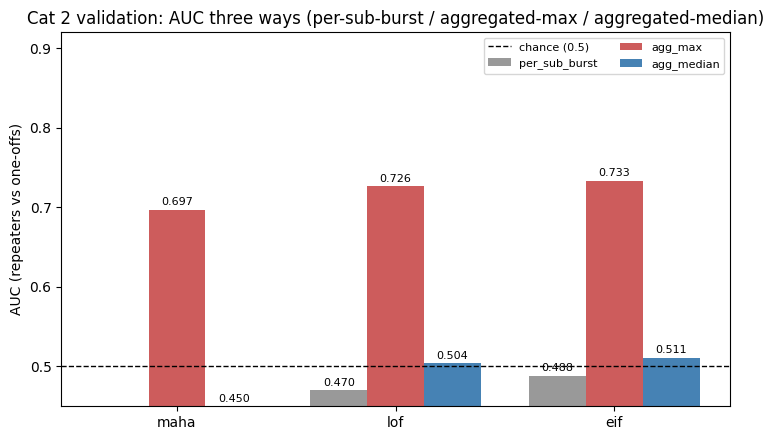

In [8]:
# Summary figure: the AUC three ways, per method. This is the clearest single picture of
# the validation. Where agg_max (red) towers over agg_median (blue), that method was riding
# the max-of-many volume effect rather than a real per-source shift. Read agg_median as the
# honest 'is the source itself odd' answer; the dashed line is chance (0.5).
FIGDIR = PROJECT / 'reports' / 'Phase 1' / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

views = ['per_sub_burst', 'agg_max', 'agg_median']
view_vals = {
    'per_sub_burst': [results_psb[m]['obs_auc'] for m in methods],
    'agg_max':       [results_agg[m]['obs_auc'] for m in methods],
    'agg_median':    [results_med[m]['obs_auc'] for m in methods],
}
colors = {'per_sub_burst': '0.6', 'agg_max': 'indianred', 'agg_median': 'steelblue'}

x = np.arange(len(methods))
w = 0.26
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for i, v in enumerate(views):
    bars = ax.bar(x + (i - 1) * w, view_vals[v], width=w, color=colors[v], label=v)
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
ax.axhline(0.5, color='k', ls='--', lw=1, label='chance (0.5)')
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel('AUC (repeaters vs one-offs)')
ax.set_ylim(0.45, 0.92)
ax.set_title('Cat 2 validation: AUC three ways (per-sub-burst / aggregated-max / aggregated-median)')
ax.legend(fontsize=8, ncol=2, loc='upper right')
fig.tight_layout()
fig.savefig(FIGDIR / 'cat2_fig_auc_three_ways.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Candidate list for Phase 2. The validation shows the methods track genuine morphology, so
# their top-ranked bursts are worth a closer look on the waterfalls. The most interesting
# are the NON-repeaters near the top: repeaters are already known to be odd, so a one-off
# ranking as highly as them is a genuine, unexplained anomaly.

ranked = scores[['tns_name', 'sub_num', 'is_repeater', 'source_id']].copy()
for m in methods:
    ranked[f'{m}_rank'] = (-oriented[m]).rank(method='min').astype(int)   # 1 = most anomalous
ranked['mean_rank'] = ranked[[f'{m}_rank' for m in methods]].mean(axis=1)
ranked = ranked.sort_values('mean_rank')

rank_cols = ['maha_rank', 'lof_rank', 'eif_rank']

print('Top 20 rows by mean rank across the three methods:')
print(ranked.head(20)[['tns_name', 'sub_num', 'is_repeater', *rank_cols, 'mean_rank']].to_string(index=False))

# All-methods-agree set: in the top 10% of EVERY method independently. These are the most
# robust anomalies, flagged by distance, density AND isolation alike.
TOP = int(round(0.10 * len(scores)))
agree = ranked[(ranked[rank_cols] <= TOP).all(axis=1)]
print(f'\nIn the top {TOP} (top 10%) of ALL THREE methods: {len(agree)} rows')
print(agree.head(25)[['tns_name', 'sub_num', 'is_repeater', *rank_cols]].to_string(index=False))
if len(agree) > 25:
    print(f'  ... and {len(agree) - 25} more')

# The Phase 2 shortlist: highest-ranked NON-repeaters (the genuine, unexplained anomalies).
nonrep = ranked[~ranked['is_repeater']].head(10)
print('\nTop 10 NON-repeater anomalies (the Phase 2 shortlist):')
print(nonrep[['tns_name', 'sub_num', *rank_cols, 'mean_rank']].to_string(index=False))

Top 20 rows by mean rank across the three methods:
    tns_name  sub_num  is_repeater  maha_rank  lof_rank  eif_rank  mean_rank
FRB20200705D        0        False          2         4        18   8.000000
FRB20200122B        1         True         17         2         7   8.666667
FRB20221219D        0         True          1         2        34  12.333333
FRB20190104B        0        False         11        15        24  16.666667
FRB20210512C        0        False         10         5        44  19.666667
FRB20210222C        0        False          8         6        52  22.000000
FRB20200429A        0        False          9         8        55  24.000000
FRB20210513C        0        False         28        19        42  29.666667
FRB20190427A        0        False         37        47        22  35.333333
FRB20230422A        0         True          3        34        72  36.333333
FRB20190531E        0        False          4        23        89  38.666667
FRB20180925A        0    

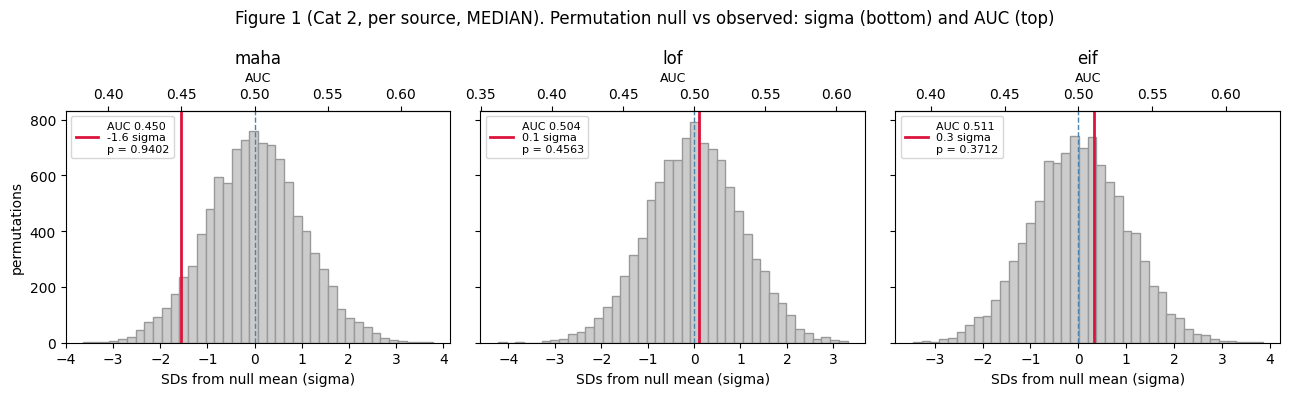

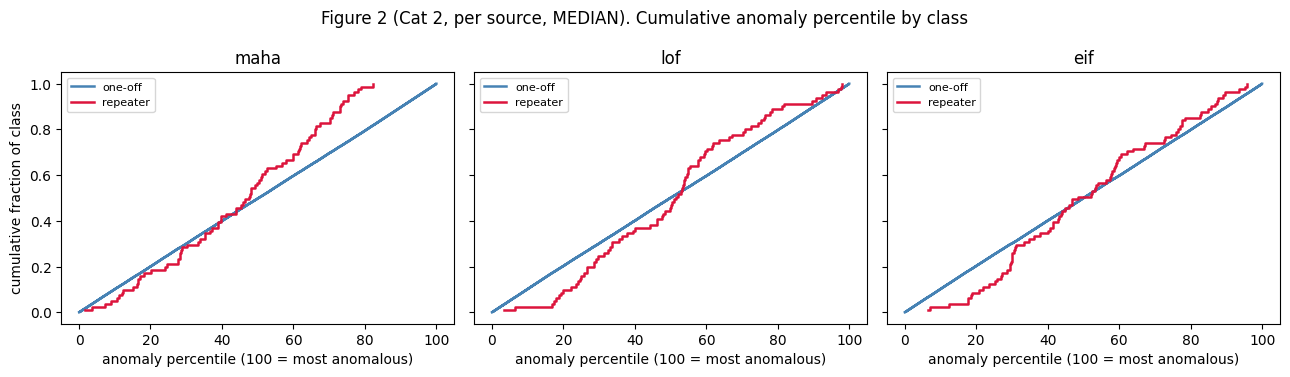

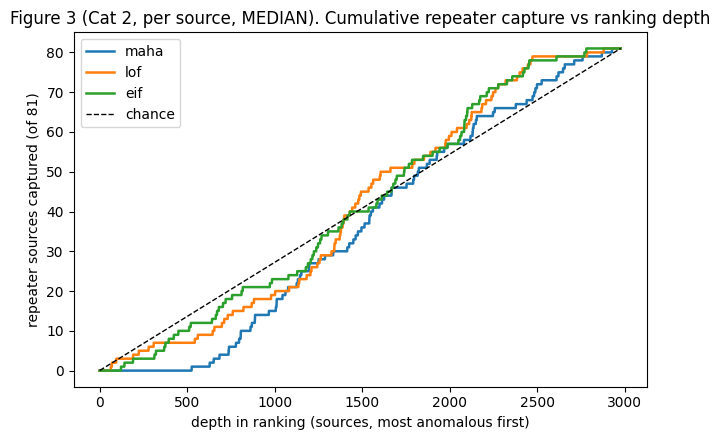

In [10]:
# Headline figures, all on the MEDIAN per-source aggregation (the honest 'is the source
# itself odd' view; see the median cross-check cell for why max overstates LOF and EIF).
# Saved with a cat2_ prefix, beside the Cat 1 figures. The agg-max story is captured
# separately by the three-way summary figure above, so these stay on the median.
FIGDIR = PROJECT / 'reports' / 'Phase 1' / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)
n_rep_src = int(med_rep_mask.sum())

# --- Figure 1: permutation null vs observed, dual scale (sigma on bottom, AUC on top) ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0), sharey=True)
for ax, m in zip(axes, methods):
    r = results_med[m]
    sd = r['null_auc'].std()
    null_sigma = (r['null_auc'] - 0.5) / sd
    obs_sigma = (r['obs_auc'] - 0.5) / sd
    ax.hist(null_sigma, bins=40, color='0.8', edgecolor='0.6')
    ax.axvline(0, color='steelblue', ls='--', lw=1)
    ax.axvline(obs_sigma, color='crimson', lw=2,
               label=f"AUC {r['obs_auc']:.3f}\n{obs_sigma:.1f} sigma\np = {r['p_auc']:.4f}")
    ax.set_title(m); ax.set_xlabel('SDs from null mean (sigma)')
    ax.legend(fontsize=8, loc='upper left')
    secax = ax.secondary_xaxis('top', functions=(lambda s, sd=sd: 0.5 + s * sd,
                                                 lambda a, sd=sd: (a - 0.5) / sd))
    secax.set_xlabel('AUC', fontsize=9)
axes[0].set_ylabel('permutations')
fig.suptitle('Figure 1 (Cat 2, per source, MEDIAN). Permutation null vs observed: sigma (bottom) and AUC (top)')
fig.tight_layout()
fig.savefig(FIGDIR / 'cat2_fig1_null_auc.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 2: cumulative distribution of anomaly percentile by class ---
# With the median view, LOF's two class curves nearly overlap (no population separation),
# which is the honest visual of its null result; Mahalanobis shows a clear repeater shift.
def ecdf(v):
    v = np.sort(v)
    return v, np.arange(1, len(v) + 1) / len(v)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, m in zip(axes, methods):
    pct = pd.Series(agg_med[m]).rank(pct=True).to_numpy() * 100   # 0-100, 100 = most anomalous
    for mask, color, label in [(~med_rep_mask, 'steelblue', 'one-off'),
                               (med_rep_mask, 'crimson', 'repeater')]:
        xv, yv = ecdf(pct[mask])
        ax.step(xv, yv, where='post', color=color, lw=1.8, label=label)
    ax.set_title(m); ax.set_xlabel('anomaly percentile (100 = most anomalous)')
    ax.legend(fontsize=8, loc='upper left')
axes[0].set_ylabel('cumulative fraction of class')
fig.suptitle('Figure 2 (Cat 2, per source, MEDIAN). Cumulative anomaly percentile by class')
fig.tight_layout()
fig.savefig(FIGDIR / 'cat2_fig2_score_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 3: cumulative repeater capture (what the top-K / tail test measures) ---
fig, ax = plt.subplots(figsize=(6.5, 4.5))
x = np.arange(1, M_med + 1)
for m in methods:
    order = np.argsort(-agg_med[m].to_numpy())
    ax.plot(x, np.cumsum(med_rep_mask[order]), lw=1.8, label=m)
ax.plot(x, x * med_baseline, 'k--', lw=1, label='chance')
ax.set_xlabel('depth in ranking (sources, most anomalous first)')
ax.set_ylabel(f'repeater sources captured (of {n_rep_src})')
ax.set_title('Figure 3 (Cat 2, per source, MEDIAN). Cumulative repeater capture vs ranking depth')
ax.legend()
fig.tight_layout()
fig.savefig(FIGDIR / 'cat2_fig3_capture_curve.png', dpi=150, bbox_inches='tight')
plt.show()